# OCR Comparison: Tesseract, EasyOCR, and PaddleOCR

Target image: `Icdar2013\\Challenge2_Test_Task12_Images\\img_1.jpg`

## Shared: Read Ground Truth

**Syntax:** `Path.read_text(encoding, errors)`

**Intro:** Load ground truth text from file for comparison. Uses `pathlib.Path` to read UTF-8 encoded text files.

In [1]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pytesseract
# Set this if Tesseract is not in PATH
pytesseract.pytesseract.tesseract_cmd = r"C:\\Program Files\\Tesseract-OCR\\tesseract.exe"



## 1. Tesseract OCR on the Same Image

### 1) Initialize Tesseract

**Syntax:** `pytesseract.pytesseract.tesseract_cmd = r"path\\to\\tesseract.exe"`

**Intro:** Configure the path to Tesseract OCR executable. Required so PyTesseract knows where to find the OCR engine on your system.

### 2) Read image

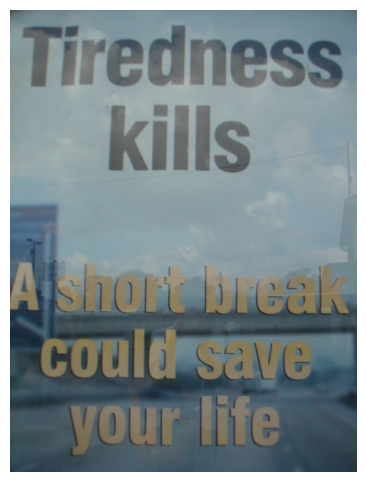

In [3]:
# image_path = Path(r"C:\Projects\OCR\icdar2013\Challenge2_Test_Task12_Images\img_1.jpg")
image_path = Path(r"D:\Handheld OCR Translator\Icdar2013\Challenge2_Test_Task12_Images\img_1.jpg")
img_rgb = plt.imread(image_path)

plt.figure(figsize=(10, 6))
plt.imshow(img_rgb)
plt.axis('off')
plt.show()



**Syntax:** `cv2.imread(filename) -> numpy.ndarray`

**Intro:** Load image from disk using OpenCV. Returns BGR image as NumPy array. Check `.shape` to verify dimensions (height, width, channels).

### 3) Apply OCR

In [4]:
detected = pytesseract.image_to_string(img_rgb, lang='eng')
detected

'*\n/ ; |\n, wail a oo\n\n'

**Syntax:** `pytesseract.image_to_string(image, lang="eng", config="--oem 3 --psm 6") -> str`

**Intro:** Extract text from image using Tesseract OCR. Returns detected text as string. Can use optional config flags for engine mode (oem) and page segmentation mode (psm).

### 4) Calculate CER and WER

**Syntax:** `levenshtein_distance(seq1, seq2) -> int` | CER = distance / ref_chars | WER = distance / ref_words

**Intro:** Compute edit distance between ground truth and predicted text. CER (Character Error Rate) and WER (Word Error Rate) measure OCR accuracy. Lower is better.

In [5]:
import re
import unicodedata


def normalize_ocr_text(text, lowercase=True, remove_punctuation=False):
    """Normalize OCR output text for fair CER/WER comparison across engines."""
    if text is None:
        text = ""
    if not isinstance(text, str):
        text = str(text)

    # Normalize unicode forms (e.g., curly quotes, accented composition).
    text = unicodedata.normalize("NFKC", text)

    # Normalize line endings and tabs from OCR outputs.
    text = text.replace("\r\n", "\n").replace("\r", "\n").replace("\t", " ")

    # Collapse all whitespace/newlines to single spaces.
    text = re.sub(r"\s+", " ", text).strip()

    if lowercase:
        text = text.lower()

    if remove_punctuation:
        # Keep only word chars and whitespace.
        text = re.sub(r"[^\w\s]", "", text)
        text = re.sub(r"\s+", " ", text).strip()

    return text


def levenshtein_distance(seq1, seq2):
    n, m = len(seq1), len(seq2)
    if n == 0:
        return m
    if m == 0:
        return n

    dp = [[0] * (m + 1) for _ in range(n + 1)]
    for i in range(n + 1):
        dp[i][0] = i
    for j in range(m + 1):
        dp[0][j] = j

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = 0 if seq1[i - 1] == seq2[j - 1] else 1
            dp[i][j] = min(
                dp[i - 1][j] + 1,      # deletion
                dp[i][j - 1] + 1,      # insertion
                dp[i - 1][j - 1] + cost  # substitution
            )

    return dp[n][m]


def compute_cer_wer(
    gt_text,
    pred_text,
    lowercase=True,
    remove_punctuation=False,
    return_normalized_text=False,
    token_level="word",
):
    """Compute CER/WER after OCR-friendly normalization.

    token_level:
        - "word": split by whitespace (default WER).
        - "char": token-level distance at character granularity (same as CER tokens).
    """
    gt_norm = normalize_ocr_text(
        gt_text,
        lowercase=lowercase,
        remove_punctuation=remove_punctuation,
    )
    pred_norm = normalize_ocr_text(
        pred_text,
        lowercase=lowercase,
        remove_punctuation=remove_punctuation,
    )

    # CER uses character-level edit distance.
    char_dist = levenshtein_distance(list(gt_norm), list(pred_norm))
    cer = char_dist / max(1, len(gt_norm))

    # WER uses token-level edit distance (usually word-based).
    if token_level == "char":
        gt_tokens = list(gt_norm)
        pred_tokens = list(pred_norm)
    else:
        gt_tokens = gt_norm.split()
        pred_tokens = pred_norm.split()

    token_dist = levenshtein_distance(gt_tokens, pred_tokens)
    wer = token_dist / max(1, len(gt_tokens))

    metrics = {
        "cer": cer,
        "wer": wer,
        "char_distance": char_dist,
        "token_distance": token_dist,
        "word_distance": token_dist,  # backward-compatible alias
        "gt_num_chars": len(gt_norm),
        "pred_num_chars": len(pred_norm),
        "gt_num_tokens": len(gt_tokens),
        "pred_num_tokens": len(pred_tokens),
        "gt_num_words": len(gt_tokens),  # backward-compatible alias
        "pred_num_words": len(pred_tokens),  # backward-compatible alias
        "normalization": {
            "lowercase": lowercase,
            "remove_punctuation": remove_punctuation,
            "token_level": token_level,
        },
    }

    if return_normalized_text:
        metrics["gt_normalized"] = gt_norm
        metrics["pred_normalized"] = pred_norm

    return metrics


def show_metrics(name, gt_text, pred_text, **kwargs):
    metrics = compute_cer_wer(gt_text, pred_text, **kwargs)
    print(f"{name} metrics:")
    print(f"  CER: {metrics['cer']:.4f} ({metrics['char_distance']} / {metrics['gt_num_chars']})")
    print(f"  WER: {metrics['wer']:.4f} ({metrics['token_distance']} / {metrics['gt_num_tokens']})")
    print(f"  Normalization: {metrics['normalization']}")
    return metrics

In [7]:
gt_path = Path(r"D:\Handheld OCR Translator\Icdar2013\Challenge2_Test_Task1_GT (1)\gt_img_1.txt")
gt_path.resolve()

WindowsPath('D:/Handheld OCR Translator/Icdar2013/Challenge2_Test_Task1_GT (1)/gt_img_1.txt')

In [8]:
import re

raw_gt_text = gt_path.read_text(encoding="utf-8", errors="ignore")
gt_words = []
for line in raw_gt_text.splitlines():
    # ICDAR format example: x1, y1, x2, y2, "word"
    match = re.search(r'"(.*?)"\s*$', line)
    if match:
        gt_words.append(match.group(1))

# Fallback to raw text if parsing finds no quoted transcription tokens.
gt_text = " ".join(gt_words).strip() if gt_words else raw_gt_text.strip()
print("Parsed GT:", gt_text)
gt_text


Parsed GT: Tiredness kills A short break could save your life


'Tiredness kills A short break could save your life'

In [9]:
compute_cer_wer(gt_text, detected)

metrics_tesseract = show_metrics("Tesseract", gt_text, detected)

Tesseract metrics:
  CER: 0.8000 (40 / 50)
  WER: 1.0000 (9 / 9)
  Normalization: {'lowercase': True, 'remove_punctuation': False, 'token_level': 'word'}


## 2. EasyOCR on the Same Image

**Syntax:** `easyocr.Reader(["en"]).readtext(image_path)`

**Intro:** Run EasyOCR on the same input image, join detected text segments, and compute CER/WER with the shared helper functions.

### Functions used in the next EasyOCR code cells

**Syntax:** `easyocr.Reader(languages, gpu=False)`

**Intro:** Creates the OCR reader object and loads EasyOCR models for the selected language set.

**Syntax:** `reader.readtext(image, detail=1, paragraph=False)`

**Intro:** Runs OCR on the image and returns detection results (boxes, text, confidence).

**Syntax:** `" ".join(iterable)`

**Intro:** Combines recognized text segments into one string for metric calculation.

**Syntax:** `show_metrics(name, gt_text, pred_text)`

**Intro:** Calls `compute_cer_wer(...)`, then prints CER/WER and edit distances.

In [11]:
import easyocr


In [12]:
reader = easyocr.Reader(['en'], gpu=False)
easyOCR = reader.readtext(img_rgb, detail=1, paragraph=False)

easyOCR_text = " ".join([item[1] for item in easyOCR]).strip()
easyOCR_text


Using CPU. Note: This module is much faster with a GPU.
d:\Evan_OCR_Translator\Handheld-OCR-Translator\.venv\Lib\site-packages\torch\ao\nn\quantized\dynamic\modules\rnn.py:162: UserWarning: torch.quantize_per_tensor, torch.quantize_per_channel and other quantized tensor creation functions that produce tensors with dtype torch.quint8, torch.qint8, and torch.qint32 are deprecated and will be removed in a future PyTorch release. Please see https://github.com/pytorch/pytorch/issues/184982 for more information. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\quantized\Quantizer.cpp:116.)
  w_ih = torch.quantize_per_tensor(
d:\Evan_OCR_Translator\Handheld-OCR-Translator\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


'Tiredness kills Aklielkc beak could Sale yoll: Lefee'

In [13]:
metrics_easyOCR = show_metrics("EasyOCR", gt_text, easyOCR_text)
metrics_easyOCR

EasyOCR metrics:
  CER: 0.2800 (14 / 50)
  WER: 0.6667 (6 / 9)
  Normalization: {'lowercase': True, 'remove_punctuation': False, 'token_level': 'word'}


{'cer': 0.28,
 'wer': 0.6666666666666666,
 'char_distance': 14,
 'token_distance': 6,
 'word_distance': 6,
 'gt_num_chars': 50,
 'pred_num_chars': 52,
 'gt_num_tokens': 9,
 'pred_num_tokens': 8,
 'gt_num_words': 9,
 'pred_num_words': 8,
 'normalization': {'lowercase': True,
  'remove_punctuation': False,
  'token_level': 'word'}}

## 3. PaddleOCR on the Same Image

**Syntax:** `PaddleOCR(...).predict(image_path)`

**Intro:** Run PaddleOCR on the same image, flatten recognized text lines, and evaluate with the same CER/WER function for side-by-side comparison.

### Functions used in the next PaddleOCR code cells

**Syntax:** `PaddleOCR(use_textline_orientation=True, lang="en")`

**Intro:** Initializes PaddleOCR with English recognition and text-line orientation handling.

**Syntax:** `ocr.predict(image_path)`

**Intro:** Runs OCR and returns page-level prediction objects that include recognized texts.

**Syntax:** `page.get("rec_texts", [])`

**Intro:** Reads recognized text lines safely from each page prediction.

**Syntax:** `" ".join(iterable)`

**Intro:** Merges recognized lines into one string for metric calculation.

**Syntax:** `show_metrics(name, gt_text, pred_text)`

**Intro:** Uses `compute_cer_wer(...)` and prints CER/WER with distances.

In [14]:
from paddleocr import PaddleOCR


d:\Evan_OCR_Translator\Handheld-OCR-Translator\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [15]:
paddle_reader = PaddleOCR(
    use_textline_orientation=True,
    lang="en",
    device="cpu",
    enable_mkldnn=False,
    enable_hpi=False,
    engine="paddle",
)
paddle_result = paddle_reader.predict(str(image_path))

Creating model: ('PP-LCNet_x1_0_doc_ori', None, 'paddle')
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\14zj2\.paddlex\official_models\PP-LCNet_x1_0_doc_ori`.
d:\Evan_OCR_Translator\Handheld-OCR-Translator\.venv\Lib\site-packages\paddle\utils\cpp_extension\extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('UVDoc', None, 'paddle')
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\14zj2\.paddlex\official_models\UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None, 'paddle')
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\14zj2\.paddlex\official_models\PP-LCNet_x1_0_textline_ori`.

In [16]:
paddle_result

[{'input_path': 'D:\\Handheld OCR Translator\\Icdar2013\\Challenge2_Test_Task12_Images\\img_1.jpg',
  'page_index': None,
  'doc_preprocessor_res': {'input_path': None,
   'page_index': None,
   'input_img': array([[[ 64, ...,  59],
           ...,
           [111, ...,  85]],
   
          ...,
   
          [[ 65, ...,  43],
           ...,
           [ 67, ...,  36]]], shape=(1280, 960, 3), dtype=uint8),
   'model_settings': {'use_doc_orientation_classify': True,
    'use_doc_unwarping': True},
   'angle': 0,
   'rot_img': array([[[ 64, ...,  59],
           ...,
           [111, ...,  85]],
   
          ...,
   
          [[ 65, ...,  43],
           ...,
           [ 67, ...,  36]]], shape=(1280, 960, 3), dtype=uint8),
   'output_img': array([[[142, ..., 117],
           ...,
           [148, ..., 111]],
   
          ...,
   
          [[ 82, ...,  78],
           ...,
           [ 85, ...,  47]]], shape=(1280, 960, 3), dtype=uint8)},
  'dt_polys': [array([[  0,   0],
          

In [17]:
texts = []
for page in paddle_result:
    texts.extend(page.get("rec_texts", []))

paddle_text = " ".join(texts).strip()
paddle_text

'Tiredness kills short break could save your life'

In [18]:
metrics_paddleocr = show_metrics("PaddleOCR", gt_text, paddle_text)

PaddleOCR metrics:
  CER: 0.0400 (2 / 50)
  WER: 0.1111 (1 / 9)
  Normalization: {'lowercase': True, 'remove_punctuation': False, 'token_level': 'word'}


## 4. Save Outputs (All Methods)

**Syntax:** `Path.mkdir(exist_ok=True)` | `Path.write_text(content, encoding="utf-8")`

**Intro:** Create output directory and save OCR text outputs for all three methods (Tesseract, EasyOCR, PaddleOCR).

In [20]:
out_dir = Path("Outputs")
out_dir.mkdir(parents=True, exist_ok=True)

text_outputs = {
    "Tesseract": detected.strip(),
    "EasyOCR": easyOCR_text.strip(),
    "PaddleOCR": paddle_text.strip(),
}

for method_name,detected_text in text_outputs.items():
    output_file = out_dir / f"{method_name}_output.txt"
    output_file.write_text(detected_text, encoding="utf-8")
    print(f"Saved {method_name} output to {output_file}")


Saved Tesseract output to Outputs\Tesseract_output.txt
Saved EasyOCR output to Outputs\EasyOCR_output.txt
Saved PaddleOCR output to Outputs\PaddleOCR_output.txt
